In [1]:
!pip install einops natsort

In [2]:
import os
# Clone if the folder does not exist
if not os.path.exists('/content/Restormer'):
    !git clone https://github.com/swz30/Restormer.git

%cd /content/Restormer

# Create the weights folder and download
os.makedirs('Motion_Deblurring/pretrained_models', exist_ok=True)
if not os.path.exists('Motion_Deblurring/pretrained_models/motion_deblurring.pth'):
    !wget -P Motion_Deblurring/pretrained_models/ https://github.com/swz30/Restormer/releases/download/v1.0/motion_deblurring.pth

Cloning into 'Restormer'...
remote: Enumerating objects: 312, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 312 (delta 78), reused 76 (delta 76), pack-reused 189 (from 1)
Receiving objects: 100% (312/312), 1.55 MiB | 36.85 MiB/s, done.
Resolving deltas: 100% (131/131), done.
/content/Restormer
--2026-06-13 08:18:43--  https://github.com/swz30/Restormer/releases/download/v1.0/motion_deblurring.pth
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/418793252/55c7bcd2-cb39-4d8a-adc4-acf6f6131c27?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-13T09%3A01%3A09Z&rscd=attachment%3B+filename%3Dmotion_deblurring.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-95

In [3]:
import sys
# Manually patching ImpImporter which was removed in Python 3.12
import pkgutil
if not hasattr(pkgutil, 'ImpImporter'):
    class ImpImporter:
        def __init__(self, path=None): pass
    pkgutil.ImpImporter = ImpImporter

# Add the Restormer folder to paths Python can find
sys.path.append('/content/Restormer')
print("compatibility patch applied.")

compatibility patch applied.


In [4]:
!pip install lmdb pyyaml scikit-image opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 24.8 MB/s eta 0:00:00


In [5]:
import torch
from basicsr.models.archs.restormer_arch import Restormer

# define model
model = Restormer(inp_channels=3, out_channels=3, dim=48, num_blocks=[4,6,6,8],
                  num_refinement_blocks=4, heads=[1,2,4,8], ffn_expansion_factor=2.66,
                  bias=False, LayerNorm_type='WithBias', dual_pixel_task=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# load weights
weights_path = 'Motion_Deblurring/pretrained_models/motion_deblurring.pth'
checkpoint = torch.load(weights_path, map_location=device)

if 'params' in checkpoint:
    model.load_state_dict(checkpoint['params'])
else:
    model.load_state_dict(checkpoint)

model.eval()
print(f"model loaded on {device}.")

model loaded on cuda.


processing image...


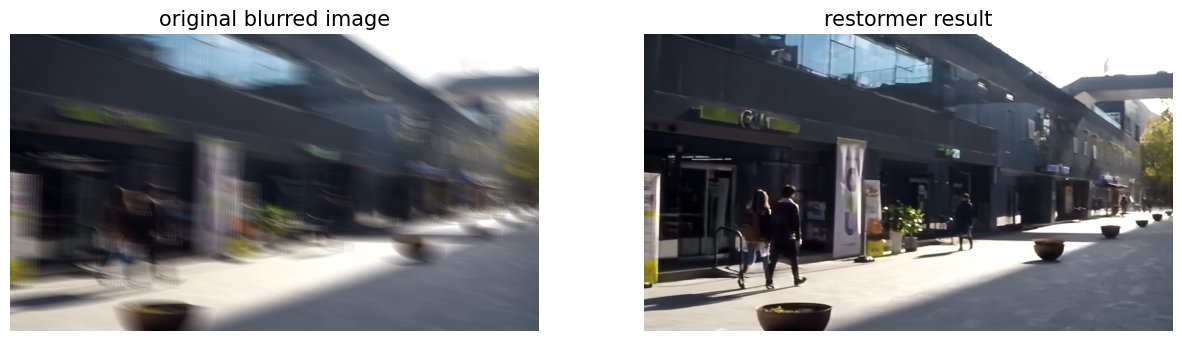

done! saved as 'deblurred_result.png'.


In [14]:
#@title 1. Run the Model and Full-Size Deblurring
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# load image
image_path = '/content/000216.png' # put your image here
img = Image.open(image_path).convert('RGB')
input_tensor = TF.to_tensor(img).unsqueeze(0).to(device)

# resize for restormer (needs to be multiple of 16)
h, w = input_tensor.shape[2], input_tensor.shape[3]
new_h = ((h // 16) + 1) * 16 if h % 16 != 0 else h
new_w = ((w // 16) + 1) * 16 if w % 16 != 0 else w
pad_h = new_h - h
pad_w = new_w - w
input_tensor = F.pad(input_tensor, (0, pad_w, 0, pad_h), mode='reflect')

# deblurring
print("processing image...")
with torch.no_grad():
    restored = model(input_tensor)

# remove padding
restored = restored[:, :, :h, :w]
restored = torch.clamp(restored, 0, 1).cpu().detach().squeeze(0)
restored_img = TF.to_pil_image(restored)

# plot results
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("original blurred image", fontsize=15)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(restored_img)
plt.title("restormer result", fontsize=15)
plt.axis('off')
plt.show()

restored_img.save('deblurred_result.png')
print("done! saved as 'deblurred_result.png'.")

In [15]:
#@title 2. Resize Image for XAI Analysis
import torchvision.transforms as T

# downscale the image so the xai stuff doesn't take forever
NEW_H, NEW_W = 256, 448
resize_transform = T.Resize((NEW_H, NEW_W))
small_img = resize_transform(img)

input_tensor_small = TF.to_tensor(small_img).unsqueeze(0).to(device)

print(f"resized to {NEW_H}x{NEW_W} for XAI.")

resized to 256x448 for XAI.


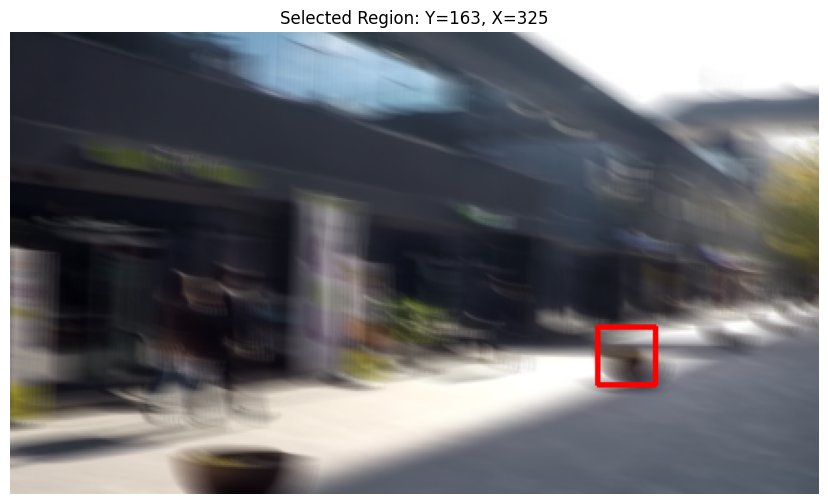

In [19]:
#@title 🎯 STEP 3: Define Target Region { run: "auto" }
TARGET_Y = 163 #@param {type:"slider", min:0, max:224, step:1}
TARGET_X = 325 #@param {type:"slider", min:0, max:416, step:1}
PATCH_SIZE = 32 #@param {type:"slider", min:16, max:128, step:8}

# Boundary Check
TARGET_Y = max(0, min(TARGET_Y, NEW_H - PATCH_SIZE))
TARGET_X = max(0, min(TARGET_X, NEW_W - PATCH_SIZE))

# Preview Drawing
preview_img = np.array(small_img).copy()
cv2.rectangle(preview_img, (TARGET_X, TARGET_Y), (TARGET_X+PATCH_SIZE, TARGET_Y+PATCH_SIZE), (255, 0, 0), 2)
plt.figure(figsize=(12, 6))
plt.imshow(preview_img)
plt.title(f"Selected Region: Y={TARGET_Y}, X={TARGET_X}")
plt.axis("off")
plt.show()

memory cleared. starting analysis for Y:163, X:325
LAM took 0.4912 seconds
calculating perturbation map...


processing: 100%|██████████| 32/32 [04:22<00:00,  8.21s/it]


perturbation took 262.6958 seconds

--- XAI Summary ---
LAM time: 0.4912s
Perturbation time: 262.6958s
-------------------


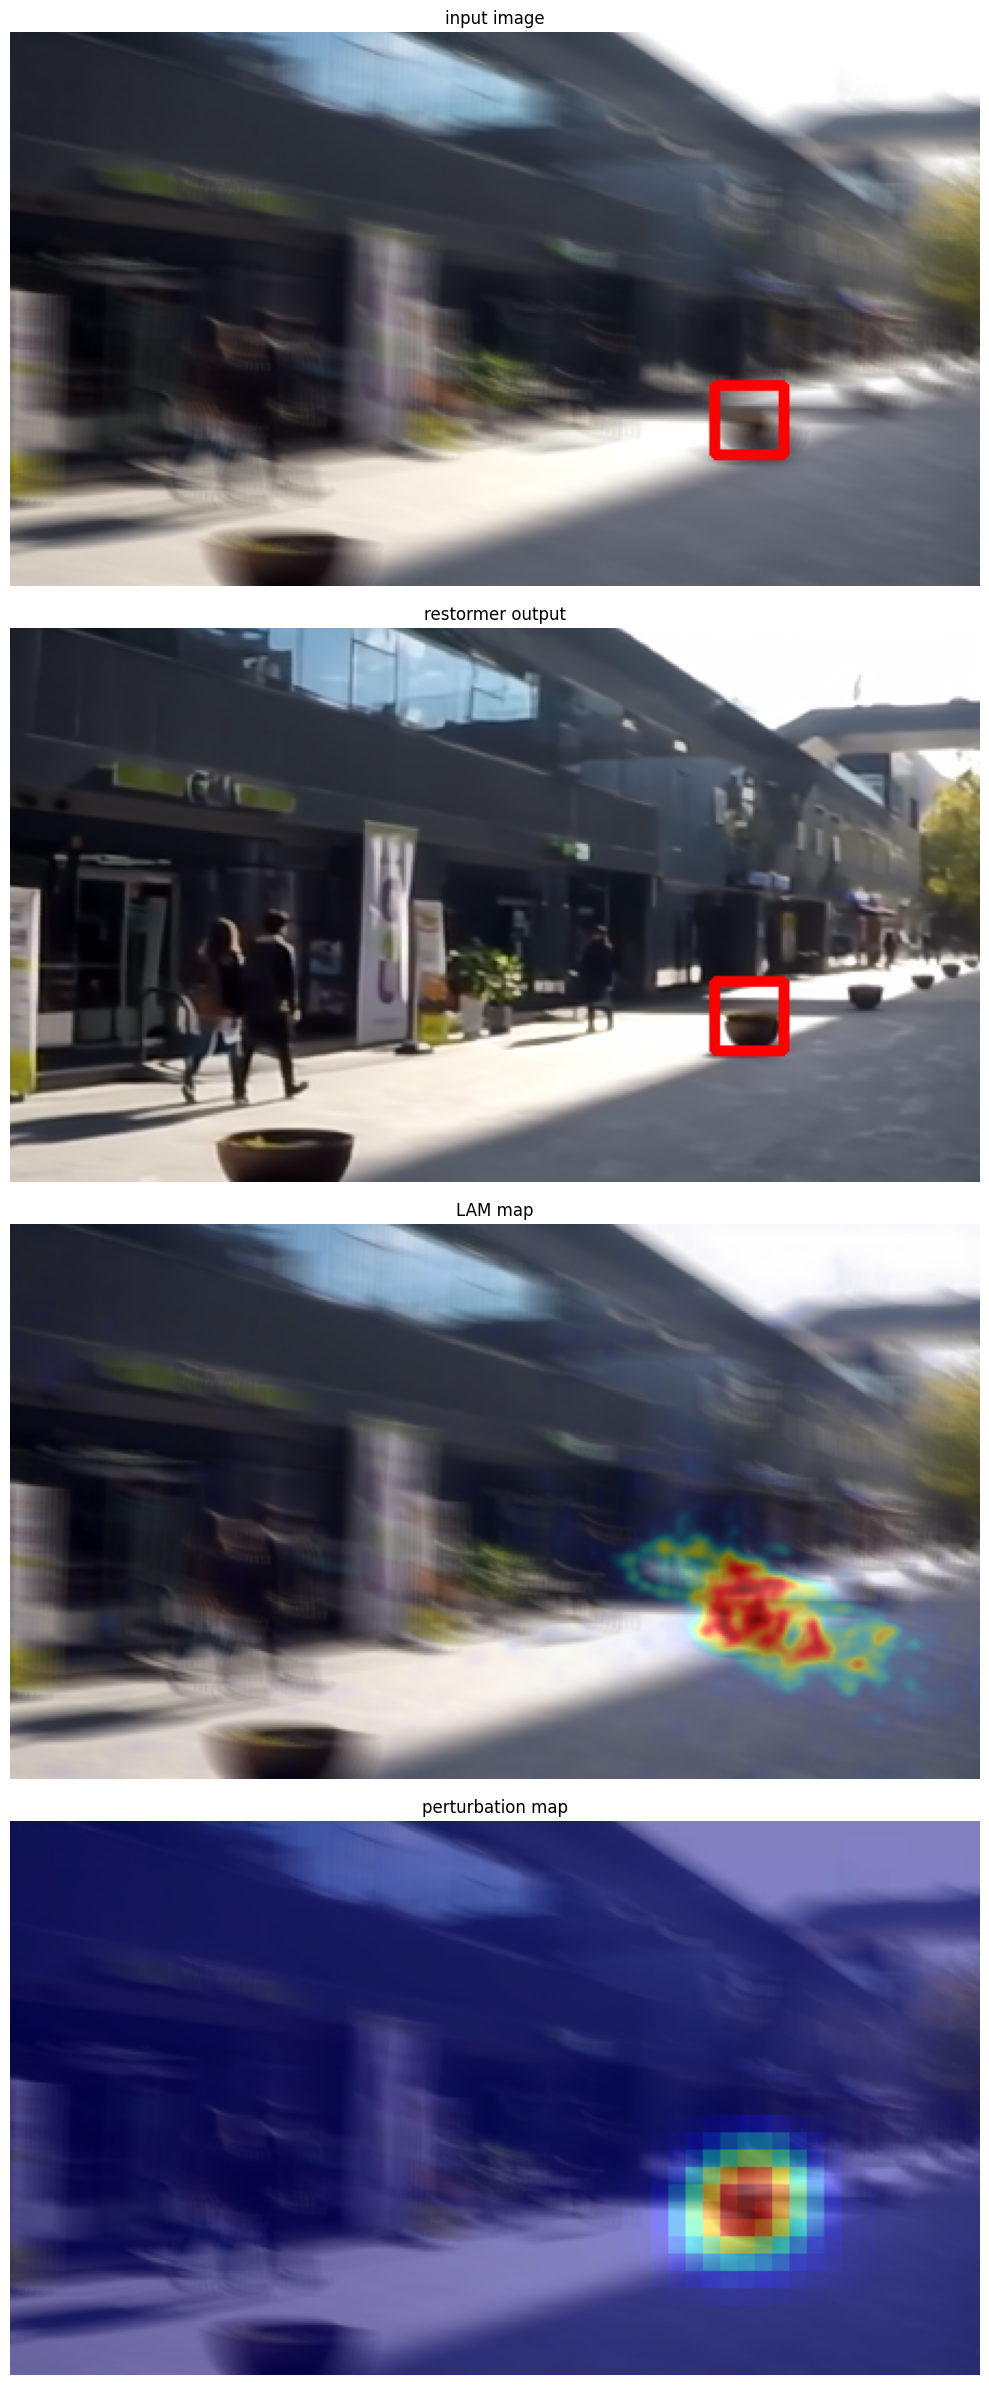


saving images...
saved 1_clean_input.png
saved 2_restormer_output.png
saved 3_lam_analysis.png
saved 4_perturbation_map.png
downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
#@title STEP 4: CLEAN XAI Analysis
from tqdm import tqdm
import gc
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import time

# clean memory & gradients
plt.close('all')
if input_tensor_small.grad is not None:
    input_tensor_small.grad.zero_()
model.zero_grad()
gc.collect()
torch.cuda.empty_cache()

print(f"memory cleared. starting analysis for Y:{TARGET_Y}, X:{TARGET_X}")

# LAM
start_lam = time.time()

input_tensor_small.requires_grad_(True)
model.eval()

restored_small = model(input_tensor_small)
target_patch = restored_small[0, :, TARGET_Y:TARGET_Y+PATCH_SIZE, TARGET_X:TARGET_X+PATCH_SIZE]

loss = target_patch.sum()
loss.backward()

raw_lam = input_tensor_small.grad.detach().abs().squeeze(0).sum(dim=0).cpu().numpy()
input_tensor_small.grad = None

vmax = np.percentile(raw_lam, 99)
clipped_lam = np.clip(raw_lam, 0, vmax)
smoothed_lam = gaussian_filter(clipped_lam, sigma=2.0)
smoothed_lam = (smoothed_lam - smoothed_lam.min()) / (smoothed_lam.max() - smoothed_lam.min() + 1e-8)

input_tensor_small.requires_grad_(False)

end_lam = time.time()
lam_duration = end_lam - start_lam
print(f"LAM took {lam_duration:.4f} seconds")


# PERTURBATION (LIME)
print("calculating perturbation map...")
start_pert = time.time()

with torch.no_grad():
    baseline_output = model(input_tensor_small)
    baseline_patch = baseline_output[0, :, TARGET_Y:TARGET_Y+PATCH_SIZE, TARGET_X:TARGET_X+PATCH_SIZE].detach()

perturbation_map = np.zeros((NEW_H, NEW_W))
stride = 8
box_size = 32

with torch.no_grad():
    for y in tqdm(range(0, NEW_H, stride), desc="processing"):
        for x in range(0, NEW_W, stride):
            masked_input = input_tensor_small.clone()
            y_end = min(y + box_size, NEW_H)
            x_end = min(x + box_size, NEW_W)
            masked_input[0, :, y:y_end, x:x_end] = 0.0

            masked_output = model(masked_input)
            masked_patch = masked_output[0, :, TARGET_Y:TARGET_Y+PATCH_SIZE, TARGET_X:TARGET_X+PATCH_SIZE]

            error = torch.nn.functional.l1_loss(masked_patch, baseline_patch).item()
            perturbation_map[y:y_end, x:x_end] += error

perturbation_map = (perturbation_map - perturbation_map.min()) / (perturbation_map.max() - perturbation_map.min() + 1e-8)

end_pert = time.time()
pert_duration = end_pert - start_pert
print(f"perturbation took {pert_duration:.4f} seconds")

# SUMMARY
print("\n--- XAI Summary ---")
print(f"LAM time: {lam_duration:.4f}s")
print(f"Perturbation time: {pert_duration:.4f}s")
print("-------------------")

# VISUALIZATION
img_np = np.array(small_img).copy()
restored_np = restored_small.detach().cpu().squeeze(0).clamp(0, 1).permute(1, 2, 0).numpy()
restored_np = (restored_np * 255).astype(np.uint8)

lam_heatmap_color = cv2.applyColorMap(np.uint8(255 * smoothed_lam), cv2.COLORMAP_JET)
lam_heatmap_color = cv2.cvtColor(lam_heatmap_color, cv2.COLOR_BGR2RGB)
alpha_mask = smoothed_lam[..., np.newaxis]
enhanced_lam_overlay = (img_np * (1 - alpha_mask * 0.7) + lam_heatmap_color * (alpha_mask * 0.7)).astype(np.uint8)

pert_heatmap = cv2.applyColorMap(np.uint8(255 * perturbation_map), cv2.COLORMAP_JET)
pert_heatmap = cv2.cvtColor(pert_heatmap, cv2.COLOR_BGR2RGB)
pert_overlay = cv2.addWeighted(img_np, 0.5, pert_heatmap, 0.5, 0)

def draw_target_box(image):
    temp_img = image.copy()
    cv2.rectangle(temp_img, (TARGET_X, TARGET_Y), (TARGET_X+PATCH_SIZE, TARGET_Y+PATCH_SIZE), (255, 0, 0), 3)
    return temp_img

fig, axes = plt.subplots(4, 1, figsize=(10, 24))
axes[0].imshow(draw_target_box(img_np))
axes[0].set_title("input image")
axes[1].imshow(draw_target_box(restored_np))
axes[1].set_title("restormer output")
axes[2].imshow(enhanced_lam_overlay)
axes[2].set_title("LAM map")
axes[3].imshow(pert_overlay)
axes[3].set_title("perturbation map")

for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

del restored_small, target_patch, loss
gc.collect()
torch.cuda.empty_cache()

# save outputs
import os

save_list = [
    (draw_target_box(img_np), "1_clean_input.png"),
    (draw_target_box(restored_np), "2_restormer_output.png"),
    (enhanced_lam_overlay, "3_lam_analysis.png"),
    (pert_overlay, "4_perturbation_map.png")
]

print("\nsaving images...")

for img_array, file_name in save_list:
    plt.imsave(file_name, img_array)
    print(f"saved {file_name}")

try:
    from google.colab import files
    print("downloading...")
    for _, file_name in save_list:
        files.download(file_name)
except ImportError:
    pass

In [21]:
def calculate_sparsity(heatmap):
    # Measures how focused the map is (between 0-1)
    # If close to 1, it means the method is looking at very specific points.
    heatmap = heatmap / np.sum(heatmap)
    sparsity = 1.0 - (np.linalg.norm(heatmap.flatten(), 1)**2 / (len(heatmap.flatten()) * np.linalg.norm(heatmap.flatten(), 2)**2))
    return sparsity

print(f"LAM Sparsity: {calculate_sparsity(smoothed_lam)}")
print(f"Perturbation Sparsity: {calculate_sparsity(perturbation_map)}")

LAM Sparsity: 0.7459605932235718
Perturbation Sparsity: 0.9445682839255487
